This script does cluster assignment in Acropora using DFA from the package Adegenet\
It also calculates ADMIXTURE ancestry, and makes figures\
Author Jaelyn Bos

In [1]:
#Make sure R can find packages installed with Conda
.libPaths('/hb/home/jbos/.conda/envs/vcfR')
.libPaths("/hb/home/jbos/.conda/envs/vcfR/lib/R/library")

In [2]:
#Load packages
library(tidyverse)
library(vcfR)
library(adegenet)
library(poppr)
library(cowplot)
library(grid)
library(hierfstat)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

   *****       ***   vcfR   ***       *****
   This is vcfR 1.15.0 
     browseVignettes('vcfR') # Documentation
     citation('vcfR') # Citation
   *****       *****      *****       *****


Loading required package: ade4


   /// adegenet 2.1.11 is loaded ////////////

   > overview: '?adegenet'
   > tutorials/doc/questions: 'adegenetWeb()' 
   > bug reports/feature requests: adegenetIssues()



Registered S3 method overwritten by 'pegas':
  method      from
  print.am

In [3]:
#Load in SNP data in VCF format
all_snps <- read.vcfR("/scratch/jbos/combined_snps_copy/pruned_snps.vcf")

Scanning file to determine attributes.
File attributes:
  meta lines: 289
  header_line: 290
  variant count: 1838
  column count: 310
Meta line 289 read in.
All meta lines processed.
gt matrix initialized.
Character matrix gt created.
  Character matrix gt rows: 1838
  Character matrix gt cols: 310
  skip: 0
  nrows: 1838
  row_num: 0
Processed variant: 1838
All variants processed


In [4]:
#Convert to genind format
genind_snps <- vcfR2genind(all_snps)

In [5]:
#Read in eigenvectors and eigenvalues created with Plink2
eigenval <- read.table("/scratch/jbos/combined_snps_copy/pca_pruned.eigenval", header = FALSE, sep = " ")
eigenvec <- read.table("/scratch/jbos/combined_snps_copy/pca_pruned.eigenvec", header = FALSE, sep = "\t")

In [6]:
#Rename columns
colnames(eigenvec) <-c ('Sample_ID', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10')

In [7]:
#Calculate % of variation accounted for by each of top five principal components
varPC1 <- (eigenval[1,1] / sum(eigenval$V1))*100
varPC2 <- (eigenval[2,1] / sum(eigenval$V1))*100
varPC3 <- (eigenval[3,1] / sum(eigenval$V1))*100
varPC4 <- (eigenval[4,1] / sum(eigenval$V1))*100
varPC5 <- (eigenval[5,1] / sum(eigenval$V1))*100

In [8]:
#Look at percent variation for top 5 PCs
varPC1
varPC2
varPC3
varPC4
varPC5

[1] 31.29182

[1] 20.80498

[1] 15.84297

[1] 8.925335

[1] 6.452741

In [9]:
#Create 'island' value for Cebu vs. Leyte province (note that Camotes are in Cebu province)
#Create 'Pop' variable for sampling site
eigenvec$Island <- substr(eigenvec$Sample_ID,start=1,stop=3)
eigenvec$Pop <- substr(eigenvec$Sample_ID,start=1,stop=5)

In [10]:
#Read in metadata with distance to shore for each sample
metadat<-read.csv('metadata_shoredist.csv')

In [11]:
#Join variables
metadat_merge<-inner_join(eigenvec,metadat)

Joining with `by = join_by(Sample_ID)`


In [12]:
#Check relationships between PCs and latitude
summary(lm(PC1 ~ lat, data=metadat_merge))
summary(lm(PC2 ~ lat, data=metadat_merge))
summary(lm(PC3 ~ lat, data=metadat_merge))
summary(lm(PC4 ~ lat, data=metadat_merge))


Call:
lm(formula = PC1 ~ lat, data = metadat_merge)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.09280 -0.03545 -0.02119  0.06458  0.09389 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept) -0.17897    0.06932  -2.582   0.0104 *
lat          0.01686    0.00669   2.521   0.0123 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.05613 on 267 degrees of freedom
  (17 observations deleted due to missingness)
Multiple R-squared:  0.02324,	Adjusted R-squared:  0.01958 
F-statistic: 6.353 on 1 and 267 DF,  p-value: 0.0123



Call:
lm(formula = PC2 ~ lat, data = metadat_merge)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.09999 -0.03549  0.01314  0.02414  0.10704 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept) -0.015262   0.072865  -0.209    0.834
lat          0.001377   0.007032   0.196    0.845

Residual standard error: 0.059 on 267 degrees of freedom
  (17 observations deleted due to missingness)
Multiple R-squared:  0.0001435,	Adjusted R-squared:  -0.003601 
F-statistic: 0.03833 on 1 and 267 DF,  p-value: 0.8449



Call:
lm(formula = PC3 ~ lat, data = metadat_merge)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.085560 -0.043513 -0.017998  0.009957  0.163247 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)  0.238140   0.073551   3.238  0.00136 **
lat         -0.022841   0.007098  -3.218  0.00145 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.05956 on 267 degrees of freedom
  (17 observations deleted due to missingness)
Multiple R-squared:  0.03733,	Adjusted R-squared:  0.03373 
F-statistic: 10.35 on 1 and 267 DF,  p-value: 0.001451



Call:
lm(formula = PC4 ~ lat, data = metadat_merge)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.126949 -0.020558 -0.004884  0.006485  0.284634 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)  0.223069   0.074116   3.010  0.00286 **
lat         -0.021608   0.007153  -3.021  0.00277 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.06002 on 267 degrees of freedom
  (17 observations deleted due to missingness)
Multiple R-squared:  0.03305,	Adjusted R-squared:  0.02943 
F-statistic: 9.126 on 1 and 267 DF,  p-value: 0.002765


In [13]:
#Check relationships between PCs and longitude
summary(lm(PC1 ~ lon, data=metadat_merge))
summary(lm(PC2 ~ lon, data=metadat_merge))
summary(lm(PC3 ~ lon, data=metadat_merge))
summary(lm(PC4 ~ lon, data=metadat_merge))


Call:
lm(formula = PC1 ~ lon, data = metadat_merge)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.08772 -0.03832 -0.02185  0.06470  0.09299 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept) -1.634072   0.843114  -1.938   0.0537 .
lon          0.013129   0.006793   1.933   0.0543 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0564 on 267 degrees of freedom
  (17 observations deleted due to missingness)
Multiple R-squared:  0.0138,	Adjusted R-squared:  0.01011 
F-statistic: 3.736 on 1 and 267 DF,  p-value: 0.05431



Call:
lm(formula = PC2 ~ lon, data = metadat_merge)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10771 -0.03827  0.01042  0.02755  0.10961 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)  1.615979   0.876492   1.844   0.0663 .
lon         -0.013028   0.007062  -1.845   0.0662 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.05864 on 267 degrees of freedom
  (17 observations deleted due to missingness)
Multiple R-squared:  0.01259,	Adjusted R-squared:  0.008889 
F-statistic: 3.404 on 1 and 267 DF,  p-value: 0.06617



Call:
lm(formula = PC3 ~ lon, data = metadat_merge)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.073411 -0.042143 -0.013839  0.003053  0.157953 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  1.34874    0.90364   1.493    0.137
lon         -0.01085    0.00728  -1.491    0.137

Residual standard error: 0.06045 on 267 degrees of freedom
  (17 observations deleted due to missingness)
Multiple R-squared:  0.008253,	Adjusted R-squared:  0.004539 
F-statistic: 2.222 on 1 and 267 DF,  p-value: 0.1372



Call:
lm(formula = PC4 ~ lon, data = metadat_merge)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.126226 -0.021488 -0.007648  0.007882  0.268553 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)  2.853780   0.895463   3.187  0.00161 **
lon         -0.022997   0.007214  -3.188  0.00161 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.05991 on 267 degrees of freedom
  (17 observations deleted due to missingness)
Multiple R-squared:  0.03666,	Adjusted R-squared:  0.03305 
F-statistic: 10.16 on 1 and 267 DF,  p-value: 0.001605


In [14]:
#Check relationships between PCs and depth
summary(lm(PC1 ~ Depth_ft, data=metadat_merge))
summary(lm(PC2 ~ Depth_ft, data=metadat_merge))
summary(lm(PC3 ~ Depth_ft, data=metadat_merge))
summary(lm(PC4 ~ Depth_ft, data=metadat_merge))


Call:
lm(formula = PC1 ~ Depth_ft, data = metadat_merge)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10369 -0.05197 -0.01759  0.06700  0.08798 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept) -0.038770   0.014200   -2.73  0.00755 **
Depth_ft     0.002338   0.001039    2.25  0.02678 * 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.05609 on 95 degrees of freedom
  (189 observations deleted due to missingness)
Multiple R-squared:  0.05058,	Adjusted R-squared:  0.04058 
F-statistic: 5.061 on 1 and 95 DF,  p-value: 0.02678



Call:
lm(formula = PC2 ~ Depth_ft, data = metadat_merge)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10487 -0.07880  0.01104  0.02923  0.09839 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept)  0.0074377  0.0163301   0.455    0.650
Depth_ft    -0.0003849  0.0011953  -0.322    0.748

Residual standard error: 0.0645 on 95 degrees of freedom
  (189 observations deleted due to missingness)
Multiple R-squared:  0.001091,	Adjusted R-squared:  -0.009424 
F-statistic: 0.1037 on 1 and 95 DF,  p-value: 0.7481



Call:
lm(formula = PC3 ~ Depth_ft, data = metadat_merge)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.056779 -0.037671 -0.022241  0.006038  0.164693 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept) -0.0048483  0.0146380  -0.331    0.741
Depth_ft    -0.0001814  0.0010714  -0.169    0.866

Residual standard error: 0.05782 on 95 degrees of freedom
  (189 observations deleted due to missingness)
Multiple R-squared:  0.0003018,	Adjusted R-squared:  -0.01022 
F-statistic: 0.02867 on 1 and 95 DF,  p-value: 0.8659



Call:
lm(formula = PC4 ~ Depth_ft, data = metadat_merge)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.091065 -0.008147  0.003999  0.013581  0.242783 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.0309550  0.0088197  -3.510 0.000688 ***
Depth_ft     0.0016288  0.0006455   2.523 0.013294 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.03484 on 95 degrees of freedom
  (189 observations deleted due to missingness)
Multiple R-squared:  0.0628,	Adjusted R-squared:  0.05294 
F-statistic: 6.366 on 1 and 95 DF,  p-value: 0.01329


In [15]:
#Check relationships between PCs and distance to shore
summary(lm(PC1 ~ SHOREDIST, data=metadat_merge))
summary(lm(PC2 ~ SHOREDIST, data=metadat_merge))
summary(lm(PC3 ~ SHOREDIST, data=metadat_merge))
summary(lm(PC4 ~ SHOREDIST, data=metadat_merge))


Call:
lm(formula = PC1 ~ SHOREDIST, data = metadat_merge)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10140 -0.03895 -0.02362  0.06841  0.09284 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -4.541e-03  3.494e-03  -1.300   0.1947  
SHOREDIST    4.852e-07  2.828e-07   1.716   0.0873 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.05693 on 284 degrees of freedom
Multiple R-squared:  0.01026,	Adjusted R-squared:  0.006774 
F-statistic: 2.944 on 1 and 284 DF,  p-value: 0.08731



Call:
lm(formula = PC2 ~ SHOREDIST, data = metadat_merge)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.09969 -0.03640  0.01376  0.02384  0.10650 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept) -1.132e-03  3.603e-03  -0.314    0.754
SHOREDIST   -1.742e-09  2.917e-07  -0.006    0.995

Residual standard error: 0.05871 on 284 degrees of freedom
Multiple R-squared:  1.255e-07,	Adjusted R-squared:  -0.003521 
F-statistic: 3.565e-05 on 1 and 284 DF,  p-value: 0.9952



Call:
lm(formula = PC3 ~ SHOREDIST, data = metadat_merge)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.078943 -0.042166 -0.012901  0.004385  0.155683 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept)  1.858e-03  3.631e-03   0.512    0.609
SHOREDIST   -3.026e-07  2.939e-07  -1.030    0.304

Residual standard error: 0.05916 on 284 degrees of freedom
Multiple R-squared:  0.003719,	Adjusted R-squared:  0.0002112 
F-statistic:  1.06 on 1 and 284 DF,  p-value: 0.304



Call:
lm(formula = PC4 ~ SHOREDIST, data = metadat_merge)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.111764 -0.015610 -0.005295  0.002795  0.281832 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept) -4.831e-04  3.635e-03  -0.133    0.894
SHOREDIST   -6.041e-08  2.943e-07  -0.205    0.837

Residual standard error: 0.05923 on 284 degrees of freedom
Multiple R-squared:  0.0001484,	Adjusted R-squared:  -0.003372 
F-statistic: 0.04214 on 1 and 284 DF,  p-value: 0.8375


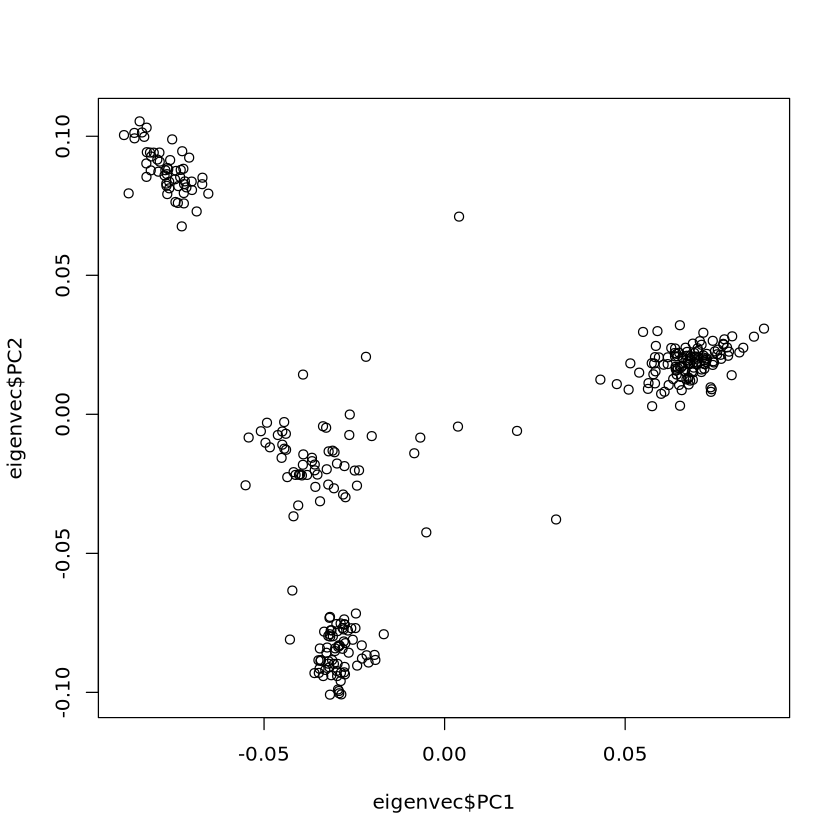

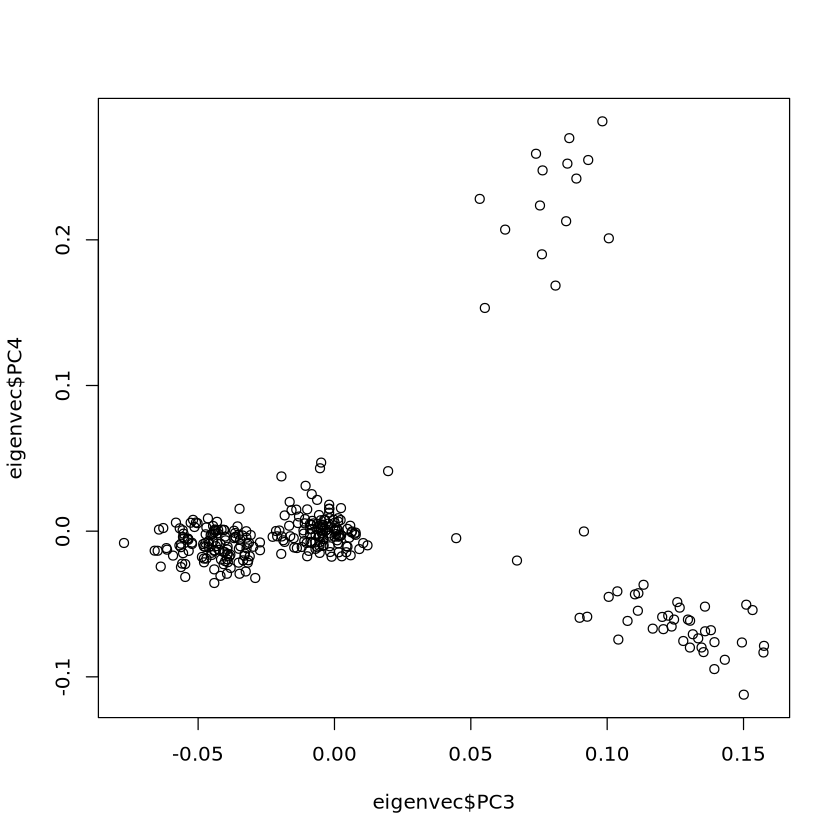

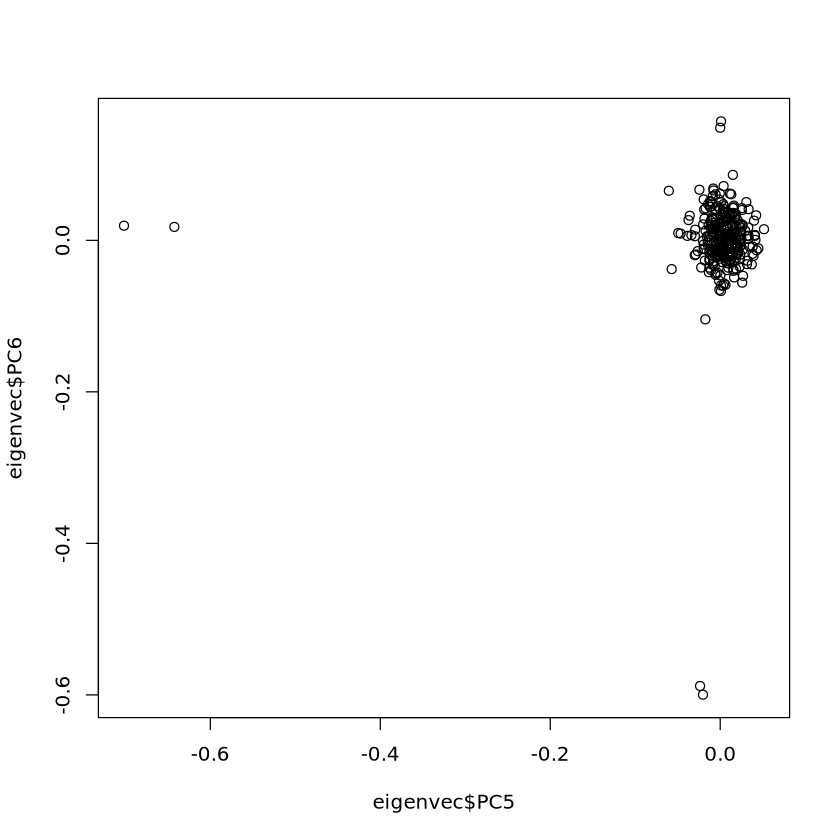

In [19]:
#Visualize data in PC space
plot(eigenvec$PC1,eigenvec$PC2)
plot(eigenvec$PC3,eigenvec$PC4)
plot(eigenvec$PC5,eigenvec$PC6)

Choose the number of clusters (>=2): 

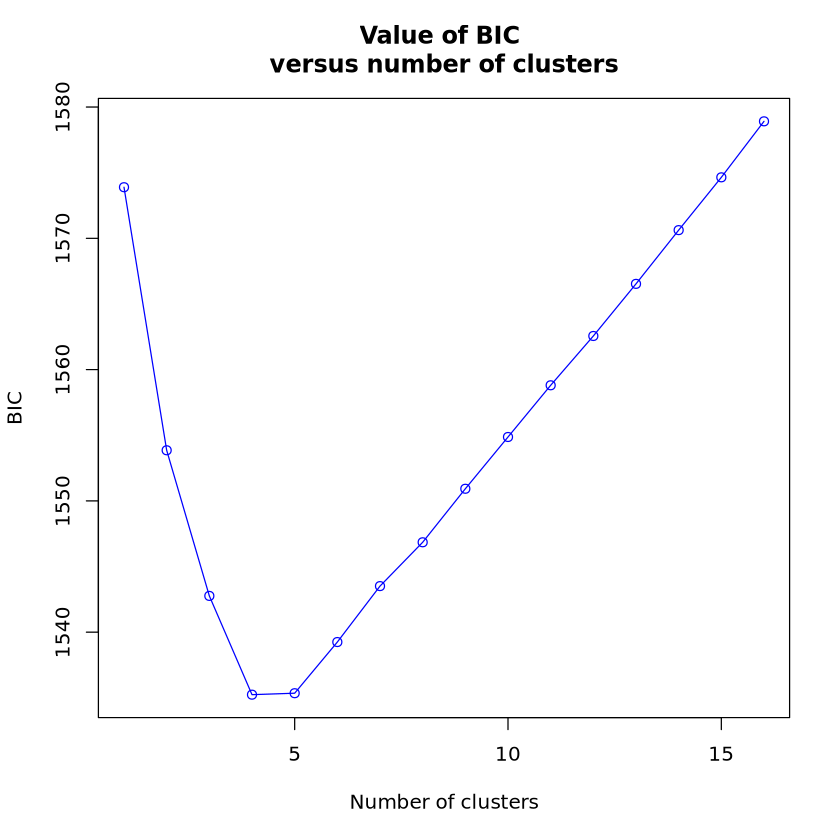

In [13]:
#Use DFA to find number of distinct clusters
set.seed(42)
grps<-find.clusters(genind_snps,max.n.clust=16,n.pca=500)

In [14]:
#Check cross validation stats
grps$Kstat

K=1      K=2      K=3      K=4      K=5      K=6      K=7      K=8 
1573.894 1553.855 1542.761 1535.239 1535.349 1539.247 1543.509 1546.847 
     K=9     K=10     K=11     K=12     K=13     K=14     K=15     K=16 
1550.923 1554.867 1558.805 1562.561 1566.532 1570.625 1574.646 1578.912

In [15]:
#Find clusters
set.seed(42)
grp<-find.clusters(genind_snps,n.clust=4,n.pca=500)
table(grp$grp)


  1   2   3   4 
120  71  53  57 

In [24]:
#Note: intentionally renumbering taxa to have most individuals in taxon1,least in taxon4
#taxa1<-names(grp$grp[grp$grp==1])
#write.csv(taxa1,file='taxa2_update.csv')
#write.table(taxa1,file='taxa2_update.txt',col.names = FALSE, row.names = FALSE, quote = FALSE)

#taxa2<-names(grp$grp[grp$grp==2])
#write.csv(taxa2,file='taxa4_update.csv')
#write.table(taxa2,file='taxa4_update.txt',col.names = FALSE, row.names = FALSE, quote = FALSE)

#taxa3<-names(grp$grp[grp$grp==3])
#write.csv(taxa3,file='taxa1_update.csv')
#write.table(taxa3,file='taxa1_update.txt',col.names = FALSE, row.names = FALSE, quote = FALSE)

#taxa4<-names(grp$grp[grp$grp==4])
#write.csv(taxa4,file='taxa3_update.csv')
#write.table(taxa4,file='taxa3_update.txt',col.names = FALSE, row.names = FALSE, quote = FALSE)

In [14]:
inds1 = read.csv('taxa1_update.csv')[,2]
inds2 = read.csv('taxa2_update.csv')[,2]
inds3 = read.csv('taxa3_update.csv')[,2]
inds4 = read.csv('taxa4_update.csv')[,2]

In [15]:
#Add taxon variable to metadata
metadat$taxon<-0
metadat[metadat$Sample_ID %in% inds1,'taxon']<-1
metadat[metadat$Sample_ID %in% inds2,'taxon']<-2
metadat[metadat$Sample_ID %in% inds3,'taxon']<-3
metadat[metadat$Sample_ID %in% inds4,'taxon']<-4

metadat_filt<-metadat[metadat$taxon>0,]
metadat_filt$taxon<-as.factor(metadat_filt$taxon)

In [16]:
#Kruskal Wallis test for depth by taxon
kruskal.test(Depth_ft ~ taxon, metadat_filt)
median(metadat_filt$Depth_ft[metadat_filt$taxon ==1],na.rm=TRUE)
median(metadat_filt$Depth_ft[metadat_filt$taxon ==2],na.rm=TRUE)
median(metadat_filt$Depth_ft[metadat_filt$taxon ==3],na.rm=TRUE)
median(metadat_filt$Depth_ft[metadat_filt$taxon ==4],na.rm=TRUE)

table(metadat_filt$Depth_ft>0)


	Kruskal-Wallis rank sum test

data:  Depth_ft by taxon
Kruskal-Wallis chi-squared = 7.0339, df = 3, p-value = 0.07083


[1] 13

[1] 12

[1] 11

[1] 9.5


TRUE 
  97 

In [17]:
#Add taxon variable to metadata
metadat_merge$taxon<-0
metadat_merge[metadat_merge$Sample_ID %in% inds1,'taxon']<-1
metadat_merge[metadat_merge$Sample_ID %in% inds2,'taxon']<-2
metadat_merge[metadat_merge$Sample_ID %in% inds3,'taxon']<-3
metadat_merge[metadat_merge$Sample_ID %in% inds4,'taxon']<-4

metadat_filt<-metadat_merge[metadat_merge$taxon>0,]
metadat_filt$taxon<-as.factor(metadat_filt$taxon)

In [18]:
#Kruskal Wallis test for distance to shore by taxon
kruskal.test(SHOREDIST ~ taxon, metadat_filt)
median(metadat_filt$SHOREDIST[metadat_filt$taxon ==1],na.rm=TRUE)
median(metadat_filt$SHOREDIST[metadat_filt$taxon ==2],na.rm=TRUE)
median(metadat_filt$SHOREDIST[metadat_filt$taxon ==3],na.rm=TRUE)
median(metadat_filt$SHOREDIST[metadat_filt$taxon ==4],na.rm=TRUE)

table(metadat_filt$SHOREDIST>0)


	Kruskal-Wallis rank sum test

data:  SHOREDIST by taxon
Kruskal-Wallis chi-squared = 4.4283, df = 3, p-value = 0.2188


[1] 245.3678

[1] 156.2536

[1] 156.0484

[1] 245.0374


FALSE  TRUE 
   25   261 

In [19]:
#Import results from ADMIXTURE for comparison with DFA and plotting
ind_tab<-read.table('/hb/scratch/jbos/combined_snps_copy/admix.fam')
ind_names<-paste(ind_tab[,1],'_',ind_tab[,2],sep="")
admix_tab<-read.table('/hb/scratch/jbos/combined_snps_copy/admix.4.Q')
colnames(admix_tab)<-c('grp1','grp2','grp3','grp4')
admix_tab<-cbind(ind_names,admix_tab)

In [20]:
#Little function to calculate which ancestry group comprises the maximum ancestry fraction of each individual
max_frac<-function(admix_row){
    x<-names(admix_row[2:5])[admix_row[2:5]==max(admix_row[2:5])]
    return(x)
    }

In [21]:
#Make separate ADMIXTURE dataframes based on max ancestry group
admix_tab$main_frac<-apply(admix_tab,MARGIN=1,FUN=max_frac)
admix_grp1<-admix_tab[admix_tab$main_frac=='grp1',]
admix_grp2<-admix_tab[admix_tab$main_frac=='grp2',]
admix_grp3<-admix_tab[admix_tab$main_frac=='grp3',]
admix_grp4<-admix_tab[admix_tab$main_frac=='grp4',]

In [22]:
#Figuring out which ADMXITURE groups correspond to which DFA groups
table(admix_grp1$ind_names %in% inds1)
table(admix_grp1$ind_names %in% inds2)
table(admix_grp1$ind_names %in% inds3)
table(admix_grp1$ind_names %in% inds4)


TRUE 
 120 


FALSE 
  120 


FALSE 
  120 


FALSE 
  120 

In [23]:
#Figuring out which ADMXITURE groups correspond to which DFA groups
table(admix_grp2$ind_names %in% inds1)
table(admix_grp2$ind_names %in% inds2)
table(admix_grp2$ind_names %in% inds3)
table(admix_grp2$ind_names %in% inds4)


FALSE 
   71 


TRUE 
  71 


FALSE 
   71 


FALSE 
   71 

In [24]:
#Figuring out which ADMXITURE groups correspond to which DFA groups
table(admix_grp3$ind_names %in% inds1)
table(admix_grp3$ind_names %in% inds2)
table(admix_grp3$ind_names %in% inds3)
table(admix_grp3$ind_names %in% inds4)


FALSE 
   56 


FALSE 
   56 


TRUE 
  56 


FALSE 
   56 

In [25]:
#Figuring out which ADMXITURE groups correspond to which DFA groups
table(admix_grp4$ind_names %in% inds1)
table(admix_grp4$ind_names %in% inds2)
table(admix_grp4$ind_names %in% inds3)
table(admix_grp4$ind_names %in% inds4)


FALSE 
   54 


FALSE 
   54 


FALSE  TRUE 
   53     1 


FALSE  TRUE 
    1    53 

In [26]:
colnames(admix_tab)

[1] "ind_names" "grp1"      "grp2"      "grp3"      "grp4"      "main_frac"

In [27]:
#Reassign ADMIXTURE column names based on DFA groups
colnames(admix_tab)<-c('ind_names','Taxa1','Taxa2','Taxa3','Taxa4','main_frac')
admix_tab$main_frac<-apply(admix_tab,MARGIN=1,FUN=max_frac)

In [28]:
#Add variable to ADMIXTURE dataframe specifying DFA group to which each individual was assigned
admix_tab$dfa_assignment<-0
admix_tab$dfa_assignment[admix_tab$ind_names %in% inds1]<-1
admix_tab$dfa_assignment[admix_tab$ind_names %in% inds2]<-2
admix_tab$dfa_assignment[admix_tab$ind_names %in% inds3]<-3
admix_tab$dfa_assignment[admix_tab$ind_names %in% inds4]<-4

In [29]:
#Check number of individuals with >1/2 ancestry from single group
table(apply(admix_tab[,2:5],MARGIN=1,FUN=max)>=0.5)
298/301

#Check number of individuals with >3/4 ancestry from single group
table(apply(admix_tab[,2:5],MARGIN=1,FUN=max)>=0.75)
291/301

#Check number of individuals with >7/8 ancestry from single group
table(apply(admix_tab[,2:5],MARGIN=1,FUN=max)>=0.875)
271/301


FALSE  TRUE 
    3   298 

[1] 0.9900332


FALSE  TRUE 
   10   291 

[1] 0.9667774


FALSE  TRUE 
   30   271 

[1] 0.9003322

In [30]:
table(admix_tab[admix_tab$dfa_assignment==1,]$Taxa1>0.5)
table(admix_tab[admix_tab$dfa_assignment==2,]$Taxa2>0.5)
table(admix_tab[admix_tab$dfa_assignment==3,]$Taxa3>0.5)
table(admix_tab[admix_tab$dfa_assignment==4,]$Taxa4>0.5)
298/301


TRUE 
 120 


TRUE 
  71 


FALSE  TRUE 
    3    54 


TRUE 
  53 

[1] 0.9900332

In [31]:
table(admix_tab[admix_tab$dfa_assignment==1,]$Taxa1>0.875)
table(admix_tab[admix_tab$dfa_assignment==2,]$Taxa2>0.875)
table(admix_tab[admix_tab$dfa_assignment==3,]$Taxa3>0.875)
table(admix_tab[admix_tab$dfa_assignment==4,]$Taxa4>0.875)
11+3+15+1
(301-30)/301


FALSE  TRUE 
   11   109 


FALSE  TRUE 
    3    68 


FALSE  TRUE 
   15    42 


FALSE  TRUE 
    1    52 

[1] 30

[1] 0.9003322

In [32]:
#Sort ADMIXTURE dataframe by main ancestry group 
admix_tab<-admix_tab[order(admix_tab$main_frac),]

In [33]:
#Assign taxa to colors, for plotting
taxa_colors <- c("Taxon1" = "#440154FF","Taxon2" = "#31688EFF","Taxon3" = "#35B779FF","Taxon4" = "#FDE725FF",'Unassigned' = "#FFFFFF")

In [34]:
admix_tab<-admix_tab[,1:6]

In [35]:
#Create long form dataframe for plotting
admix_long<-pivot_longer(admix_tab,cols=c('Taxa1','Taxa2','Taxa3','Taxa4'),names_to='Taxon')
admix_long$ind_names<-factor(admix_long$ind_names, levels = unique(admix_long$ind_names)) 

In [36]:
#Create correctly colored points for plotting
cors <- as.data.frame(eigenvec$Sample_ID)
cors$TaxaColors<-'#FFFFFF'
cors$Taxon<-'Unassigned'

colnames(cors)<-c('Sample_ID','TaxaColors','Taxon')

cors[cors$Sample_ID %in% inds1,2]<-'#440154FF'
cors[cors$Sample_ID %in% inds2,2]<-'#31688EFF'
cors[cors$Sample_ID %in% inds3,2]<-'#35B779FF'
cors[cors$Sample_ID %in% inds4,2]<-'#FDE725FF'

cors[cors$Sample_ID %in% inds1,3]<-'Taxon1'
cors[cors$Sample_ID %in% inds2,3]<-'Taxon2'
cors[cors$Sample_ID %in% inds3,3]<-'Taxon3'
cors[cors$Sample_ID %in% inds4,3]<-'Taxon4'

plot_points<-left_join(eigenvec,cors)

Joining with `by = join_by(Sample_ID)`


In [37]:
#Take out those points not assigned to a taxon
plot_points<-left_join(eigenvec,cors)
plot_points<-plot_points[!plot_points$Taxon=='Unassigned',]

Joining with `by = join_by(Sample_ID)`


In [38]:
#Read in site locations to get latitude
locs<-read.csv('all_Atenuis_sites_FIXED.csv')
colnames(locs)<-c('lon','lat','site')

In [39]:
#Create ADMIXTURE table ordered by latitude
admix_long$ind_names<-as.character(admix_long$ind_names) 
admix_long$site<-unlist(lapply(strsplit(admix_long$ind_names,"_"), head, 1))
admix_lat<-left_join(admix_long,locs)
admix_lat<-admix_lat[order(admix_lat$lat), ]

Joining with `by = join_by(site)`


In [40]:
#Sort ADMIXTURE dataframe by main ancestry group 
admix_tab<-admix_tab[order(admix_tab$main_frac),]
#Create long form dataframe for plotting
admix_long<-pivot_longer(admix_tab,cols=c('Taxa1','Taxa2','Taxa3','Taxa4'),names_to='Taxon')
admix_long$ind_names<-factor(admix_long$ind_names, levels = unique(admix_long$ind_names)) 

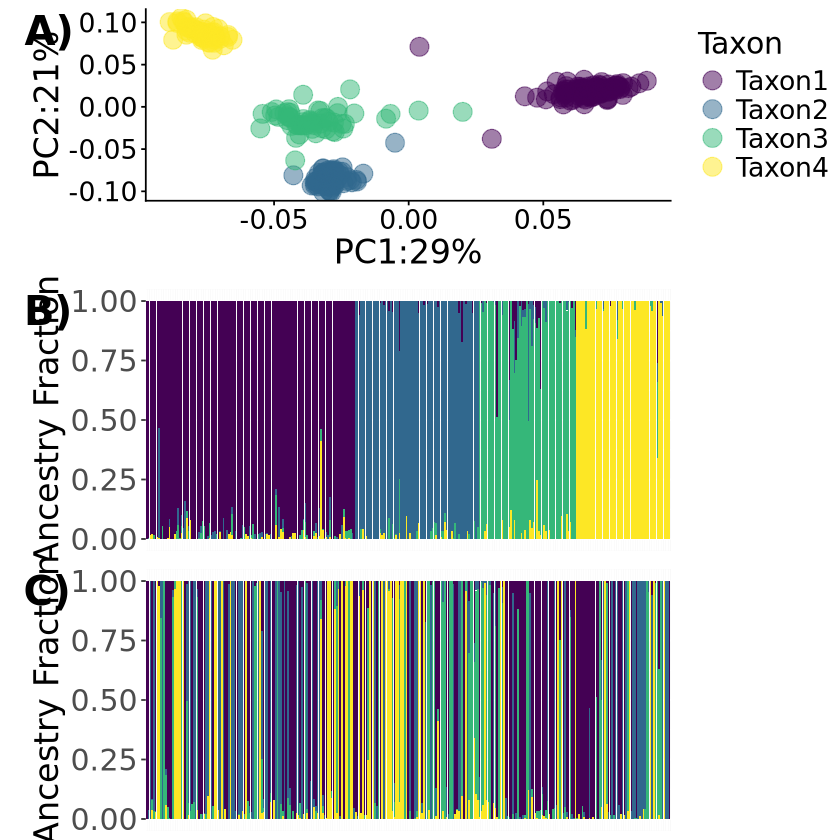

In [41]:
#Make a big unneccessarily complicated 3 panel plot
p1 <- ggplot(plot_points, aes(x=PC1, y=PC2, color=Taxon)) +
  geom_point(shape=19, size=5, alpha=0.5) +
  theme_classic() +
  scale_color_manual(values = taxa_colors) +
  theme(
    plot.title = element_text(size = 24),
    axis.text.x = element_text(size = 16),
    axis.text.y = element_text(size = 16),
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 18),
    axis.title.x = element_text(size = 20),
    axis.title.y = element_text(size = 20))+
  labs(color = "Taxon", x = "PC1:29%", y = "PC2:21%")

plot_colors <- c("#440154FF", "#31688EFF", "#35B779FF", "#FDE725FF")

adplot <- ggplot(admix_long, aes(x = ind_names, y = value, fill = Taxon)) +
  geom_col(position = position_fill()) +
  scale_fill_manual(values = plot_colors) +
  ylab("Ancestry Fraction") +
  theme(legend.position = "none")+
  theme(
    plot.title = element_text(size = 18),
    axis.title.y = element_text(size = 20),
    axis.text.x = element_blank(),
    axis.text.y = element_text(size = 18),
    axis.title.x = element_blank(),
    axis.ticks.x = element_blank()
  )

# Third panel using admix_lat
adplot2 <- ggplot(admix_lat, aes(x = ind_names, y = value, fill = Taxon)) +
  geom_col(position = position_fill()) +
  scale_fill_manual(values = plot_colors) +
  ylab("Ancestry Fraction") +
  theme(legend.position = "none")+
  theme(
    plot.title = element_text(size = 18),
    axis.title.y = element_text(size = 20),
    axis.text.x = element_blank(),
    axis.text.y = element_text(size = 18),
    axis.title.x = element_blank(),
    axis.ticks.x = element_blank()
  )

p1_adj <- p1 + theme(plot.margin = margin(5.5, 5.5, 5.5, 20, unit = "pt"))
adplot_adj <- adplot + theme(plot.margin = margin(5.5, 5.5, 5.5, 20, unit = "pt"))
adplot2_adj <- adplot2 + theme(plot.margin = margin(5.5, 5.5, 5.5, 20, unit = "pt"))

combined <- plot_grid(
  p1_adj, adplot_adj, adplot2_adj,
  labels = c("A)", "B)", "C)"),
  label_size = 24,
  ncol = 1,
  align = "v"
)

show(combined)
# --- Save to file ---
ggsave("cryptic_acropora_taxon_update.pdf", combined, width = 8, height = 10, dpi = 1200, units = "in")

In [25]:
#Check statistical significance of FSTs between DFA groups

In [59]:
#Make dataframe associating individual samples to the correct taxa
individuals<-as.data.frame(matrix(nrow=nrow(genind_snps@tab),ncol=1))
individuals$ind<-rownames(genind_snps@tab)
colnames(individuals)<-c('taxa','ind')

individuals$taxa<-0
individuals[individuals$ind %in% inds1,1]<-1
individuals[individuals$ind %in% inds2,1]<-2
individuals[individuals$ind %in% inds3,1]<-3
individuals[individuals$ind %in% inds4,1]<-4

In [60]:
#Add population variable to the genind (taxon=population)
genind_snps@pop<-as.factor(individuals$taxa)

In [61]:
#Convert to hierfstat
hstat2<-genind2hierfstat(genind_snps,pop=genind_snps@pop)

In [62]:
#Calculate pairwise FSTs based on cryptic Acropora taxa
fst_acropora<-pairwise.WCfst(hstat2)

In [63]:
#Print FSTs
fst_acropora

,1,2,3,4
1,NA,0.11777279,0.11045811,0.1568439
2,0.1177728,NA,0.09925483,0.1476028
3,0.1104581,0.09925483,NA,0.1210137
4,0.1568439,0.14760283,0.12101369,NA


In [64]:
#Read in bootstrapped distributions of null FSTs between reshuffled taxa
boot12<-ecdf(read.csv('acropora12_fst_boot.csv')[,2])
boot13<-ecdf(read.csv('acropora13_fst_boot.csv')[,2])
boot14<-ecdf(read.csv('acropora14_fst_boot.csv')[,2])
boot23<-ecdf(read.csv('acropora23_fst_boot.csv')[,2])
boot24<-ecdf(read.csv('acropora24_fst_boot.csv')[,2])
boot34<-ecdf(read.csv('acropora34_fst_boot.csv')[,2])

In [74]:
#Check simulated significance of FST between taxa 1 and 2
1- boot12(fst_acropora[1,2])

[1] 0

In [75]:
#Check simulated significance of FST between taxa 1 and 3
1- boot13(fst_acropora[1,3])

[1] 0

In [76]:
#Check simulated significance of FST between taxa 1 and 4
1- boot14(fst_acropora[1,4])

[1] 0

In [77]:
#Check simulated significance of FST between taxa 2 and 3
1- boot23(fst_acropora[2,3])

[1] 0

In [81]:
#Check simulated significance of FST between taxa 2 and 4
1- boot24(fst_acropora[2,4])

[1] 0

In [82]:
#Check simulated significance of FST between taxa 3 and 4
1- boot34(fst_acropora[3,4])

[1] 0